Ejemplo básico de teleportación:

In [9]:
import pyzx as zx
import matplotlib.pyplot as plt
from pyzx.simplify import *
def teleport_graph():

    circ = zx.Circuit(3)
    circ.add_gate("H", 1)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CNOT", 0, 1)
    circ.add_gate("H", 0)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CZ", 0, 2)

    g = circ.to_graph()

    # Extraer los nodos frontera
    entradas = g.inputs()
    salidas = g.outputs()

    # 1. INICIALIZACIÓN DEL RECURSO ENTRELAZADO (Inputs al estado |0>)
    g.set_type(entradas[1], zx.VertexType.X)
    g.set_type(entradas[2], zx.VertexType.X)

    # 2. PROYECCIONES DE MEDIDA (Colapso del Pauli Frame)
    # Salida 0: Al tener una puerta H previa, proyectar a <+| equivale a medir <0|
    g.set_type(salidas[0], zx.VertexType.X)
    # Salida 1: Proyección directa a <0| (Medida en la base Z)
    g.set_type(salidas[1], zx.VertexType.X)
    return g

# Dibujar el grafo preparatorio
graph = teleport_graph()
zx.draw(graph)


In [10]:
opt_graph = teleport_graph()

while True:
    i1 = id_simp(opt_graph)
    if i1: 
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    i2 = spider_simp(opt_graph)
    if i2:         
            fig = zx.draw(opt_graph)
            print("i2")
            display(fig)
            plt.close(fig)
    i3 = pivot_simp(opt_graph)
    if i3:           
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    if not (i1 or i2 or i3): break

while True:
    i4 = lcomp_simp(opt_graph)
    if i4: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i4")
        display(fig)
        plt.close(fig)
    i5 = pivot_boundary_simp(opt_graph)
    if i5: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i5")
        display(fig)
        plt.close(fig)
    i6 = gadget_simp(opt_graph)
    if i6:
        fig = zx.draw(opt_graph)
        print("i6")
        display(fig)
        plt.close(fig)
    i7 = pivot_gadget_simp(opt_graph)
    if i7:
        fig = zx.draw(opt_graph)
        print("i7")
        display(fig)
        plt.close(fig)
    i8 = clifford_simp(opt_graph)
    if i8:
        fig = zx.draw(opt_graph)
        print("i8")
        display(fig)
        plt.close(fig)
    if not (i4 or i5 or i6 or i7 or i8): break

i1


None

i2


None

i8


None

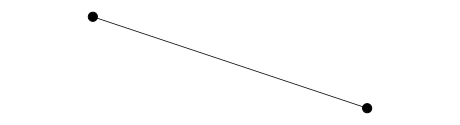

In [11]:
full_opt_graph = teleport_graph()
zx.simplify.full_reduce(full_opt_graph)
optimized_circ = zx.extract_circuit(full_opt_graph)
zx.draw_matplotlib(full_opt_graph)

In [12]:
opt_graph = teleport_graph()
id_simp(opt_graph)
spider_simp(opt_graph)#
zx.draw(opt_graph)

In [23]:
def teleport_graph_no_classic():

    circ = zx.Circuit(3)
    circ.add_gate("H", 1)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CNOT", 0, 1)
    circ.add_gate("H", 0)

    g = circ.to_graph()

    # Extraer los nodos frontera
    entradas = g.inputs()
    salidas = g.outputs()

    # 1. INICIALIZACIÓN DEL RECURSO ENTRELAZADO (Inputs al estado |0>)
    g.set_type(entradas[1], zx.VertexType.X)
    g.set_type(entradas[2], zx.VertexType.X)


    return g

# Dibujar el grafo preparatorio
graph = teleport_graph_no_classic()
zx.draw(graph)


In [26]:
opt_graph = teleport_graph_no_classic()

while True:
    i1 = id_simp(opt_graph)
    if i1: 
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    i2 = spider_simp(opt_graph)
    if i2:         
            fig = zx.draw(opt_graph)
            print("i2")
            display(fig)
            plt.close(fig)
    i3 = pivot_simp(opt_graph)
    if i3:           
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    if not (i1 or i2 or i3): break

while True:
    i4 = lcomp_simp(opt_graph)
    if i4: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i4")
        display(fig)
        plt.close(fig)
    i5 = pivot_boundary_simp(opt_graph)
    if i5: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i5")
        display(fig)
        plt.close(fig)
    i6 = gadget_simp(opt_graph)
    if i6:
        fig = zx.draw(opt_graph)
        print("i6")
        display(fig)
        plt.close(fig)
    i7 = pivot_gadget_simp(opt_graph)
    if i7:
        fig = zx.draw(opt_graph)
        print("i7")
        display(fig)
        plt.close(fig)
    i8 = clifford_simp(opt_graph)
    if i8:
        fig = zx.draw(opt_graph)
        print("i8")
        display(fig)
        plt.close(fig)
    if not (i4 or i5 or i6 or i7 or i8): break


i1


None

i2


None

i1


None

i8


None

In [17]:
def teleport_graph_2DNN():

    circ = zx.Circuit(3)
    circ.add_gate("H", 1)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CNOT", 0, 1)
    circ.add_gate("H", 0)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("SWAP", 0, 1)
    circ.add_gate("CZ", 1, 2)

    g = circ.to_graph()

    # Extraer los nodos frontera
    entradas = g.inputs()
    salidas = g.outputs()

    # 1. INICIALIZACIÓN DEL RECURSO ENTRELAZADO (Inputs al estado |0>)
    g.set_type(entradas[1], zx.VertexType.X)
    g.set_type(entradas[2], zx.VertexType.X)

    # 2. PROYECCIONES DE MEDIDA (Colapso del Pauli Frame)
    # Salida 0: Al tener una puerta H previa, proyectar a <+| equivale a medir <0|
    g.set_type(salidas[0], zx.VertexType.X)
    # Salida 1: Proyección directa a <0| (Medida en la base Z)
    g.set_type(salidas[1], zx.VertexType.X)
    return g

# Dibujar el grafo preparatorio
graph = teleport_graph_2DNN()
zx.draw(graph)

In [18]:
opt_graph = teleport_graph_2DNN()

while True:
    i1 = id_simp(opt_graph)
    if i1: 
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    i2 = spider_simp(opt_graph)
    if i2:         
            fig = zx.draw(opt_graph)
            print("i2")
            display(fig)
            plt.close(fig)
    i3 = pivot_simp(opt_graph)
    if i3:           
            fig = zx.draw(opt_graph)
            print("i1")
            display(fig)
            plt.close(fig)
    if not (i1 or i2 or i3): break

while True:
    i4 = lcomp_simp(opt_graph)
    if i4: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i4")
        display(fig)
        plt.close(fig)
    i5 = pivot_boundary_simp(opt_graph)
    if i5: 
        fig = zx.draw_matplotlib(opt_graph)
        print("i5")
        display(fig)
        plt.close(fig)
    i6 = gadget_simp(opt_graph)
    if i6:
        fig = zx.draw(opt_graph)
        print("i6")
        display(fig)
        plt.close(fig)
    i7 = pivot_gadget_simp(opt_graph)
    if i7:
        fig = zx.draw(opt_graph)
        print("i7")
        display(fig)
        plt.close(fig)
    i8 = clifford_simp(opt_graph)
    if i8:
        fig = zx.draw(opt_graph)
        print("i8")
        display(fig)
        plt.close(fig)
    if not (i4 or i5 or i6 or i7 or i8): break

i1


None

i2


None

i8


None

Evaluando rama de medida: m0=0, m1=0


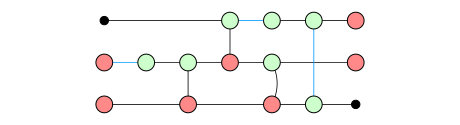

Evaluando rama de medida: m0=0, m1=1


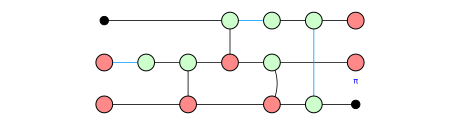

Evaluando rama de medida: m0=1, m1=0


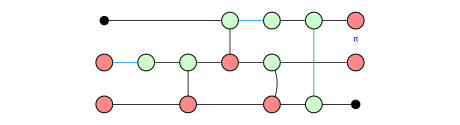

Evaluando rama de medida: m0=1, m1=1


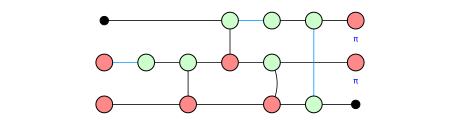

In [51]:
from fractions import Fraction
def teleport_graph_parametric(m0: int, m1: int):

    circ = zx.Circuit(3)
    circ.add_gate("H", 1)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CNOT", 0, 1)
    circ.add_gate("H", 0)
    circ.add_gate("CNOT", 1, 2)
    circ.add_gate("CZ", 0, 2)

    g = circ.to_graph()

    # Extraer los nodos frontera
    entradas = g.inputs()
    salidas = g.outputs()

    # 1. INICIALIZACIÓN DEL RECURSO ENTRELAZADO (Inputs al estado |0>)
    g.set_type(entradas[1], zx.VertexType.X)
    g.set_type(entradas[2], zx.VertexType.X)

    # 2. PROYECCIONES DE MEDIDA (Colapso del Pauli Frame)
    # Salida 0: Al tener una puerta H previa, proyectar a <+| equivale a medir <0|
    g.set_type(salidas[0], zx.VertexType.X)
    g.set_phase(salidas[0], Fraction(m0, 1))
    # Salida 1: Proyección directa a <0| (Medida en la base Z)
    g.set_type(salidas[1], zx.VertexType.X)
    g.set_phase(salidas[1], Fraction(m1, 1))

    return g

resultados_medida = [(0, 0), (0, 1), (1, 0), (1, 1)]

for m0, m1 in resultados_medida:
    print(f"Evaluando rama de medida: m0={m0}, m1={m1}")
    g_estado = teleport_graph_parametric(m0, m1)
    fig = zx.draw_matplotlib(g_estado)
    display(fig)
    plt.close(fig)


Evaluando rama de medida: m0=0, m1=0


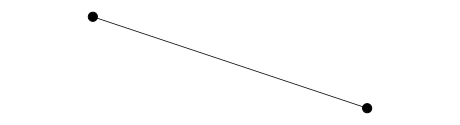

Evaluando rama de medida: m0=0, m1=1


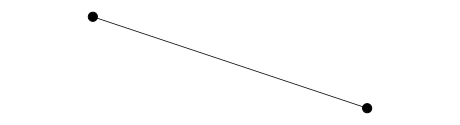

Evaluando rama de medida: m0=1, m1=0


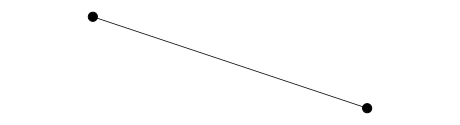

Evaluando rama de medida: m0=1, m1=1


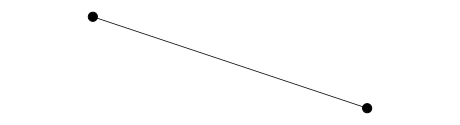

In [53]:
for m0, m1 in resultados_medida:
    print(f"Evaluando rama de medida: m0={m0}, m1={m1}")
    
    # Generar el grafo para el estado específico
    g_estado = teleport_graph_parametric(m0, m1)
    
    # Reducción algebraica completa
    zx.simplify.full_reduce(g_estado)
    
    # Verificación visual del colapso (Debe ser un único cable para los 4 casos)
    fig = zx.draw_matplotlib(g_estado)
    display(fig)
    plt.close(fig)

In [54]:
for m0, m1 in resultados_medida:
    print(f"Evaluando rama de medida: m0={m0}, m1={m1}")
    opt_graph = teleport_graph_parametric(m0, m1)
    while True:
        i1 = id_simp(opt_graph)
        if i1: 
                fig = zx.draw(opt_graph)
                print("i1")
                display(fig)
                plt.close(fig)
        i2 = spider_simp(opt_graph)
        if i2:         
                fig = zx.draw(opt_graph)
                print("i2")
                display(fig)
                plt.close(fig)
        i3 = pivot_simp(opt_graph)
        if i3:           
                fig = zx.draw(opt_graph)
                print("i1")
                display(fig)
                plt.close(fig)
        if not (i1 or i2 or i3): break

    while True:
        i4 = lcomp_simp(opt_graph)
        if i4: 
            fig = zx.draw_matplotlib(opt_graph)
            print("i4")
            display(fig)
            plt.close(fig)
        i5 = pivot_boundary_simp(opt_graph)
        if i5: 
            fig = zx.draw_matplotlib(opt_graph)
            print("i5")
            display(fig)
            plt.close(fig)
        i6 = gadget_simp(opt_graph)
        if i6:
            fig = zx.draw(opt_graph)
            print("i6")
            display(fig)
            plt.close(fig)
        i7 = pivot_gadget_simp(opt_graph)
        if i7:
            fig = zx.draw(opt_graph)
            print("i7")
            display(fig)
            plt.close(fig)
        i8 = clifford_simp(opt_graph)
        if i8:
            fig = zx.draw(opt_graph)
            print("i8")
            display(fig)
            plt.close(fig)
        if not (i4 or i5 or i6 or i7 or i8): break

Evaluando rama de medida: m0=0, m1=0


i1


None

i2


None

...

None

i2


None

i8


None